# Introduction to Inferential Statistics
## Hypothesis Testing

> **Disclaimer:** This notebook was generated with the assistance of AI and has been human-reviewed for accuracy and quality.

**Topics Covered:**
- Sample Estimates vs Population Metrics
- Z-Scores  
- Hypothesis Testing

## 1. Inferential Statistics

### What Is Inferential Statistics?

**Inferential statistics** is the branch of statistics that allows us to draw conclusions about a **population** based on data collected from a **sample**. Rather than surveying every single customer, transaction, or user (which is often impractical or impossible) we gather a representative subset and use mathematical tools to make educated, probabilistic statements about the broader group.

This stands in contrast to **descriptive statistics**, which only summarizes the data you already have. Inferential statistics asks the harder question: *what does this sample tell us about the world beyond it?*

In business data analytics, this is foundational. Companies rely on samples every day:
- A retailer surveys 500 customers to gauge satisfaction across 50,000.
- A product team runs an A/B test on 10% of users to decide a feature rollout.
- A financial analyst uses quarterly data to forecast annual trends.

Inferential statistics gives these decisions a rigorous, quantifiable basis.

---

### 1.1 Sample Estimates vs. Population Metrics

A **population** is the complete group you care about. A **sample** is the subset you actually observe. Because we rarely have access to the full population, we use **sample statistics** to *estimate* the true **population parameters**.

| Concept | Population (Truth) | Sample (Estimate) |
|---|---|---|
| Mean | μ (mu) | x̄ (x-bar) |
| Standard Deviation | σ (sigma) | s |

The key insight is that sample estimates are **random variables** — they vary from sample to sample. If you surveyed a different 500 customers tomorrow, you would get a slightly different mean. This variability is quantified by the **standard error (SE)**:

$$SE = \frac{\sigma}{\sqrt{n}}$$

where σ is the population standard deviation and n is the sample size. A larger sample produces a smaller standard error — meaning our estimate is more precise.

**Business context:** When a marketing analyst reports that the average order value is \$87.50 based on last month's transactions, that is a sample estimate. The standard error tells us how confident we can be that this is close to the true average across all possible transactions.

---

### 1.2 Z-Scores

A **z-score** measures how many standard deviations a value lies away from the mean. For a single observation:

$$z = \frac{x - \mu}{\sigma}$$

For a **sample mean**, the z-score becomes:

$$z = \frac{\bar{x} - \mu}{SE} = \frac{\bar{x} - \mu}{\sigma / \sqrt{n}}$$

This standardization is powerful because it transforms any normal distribution into the **standard normal distribution** (mean = 0, std = 1), allowing us to look up probabilities in a universal table or compute them directly.

**Interpreting z-scores:**
- z = 0 → the value equals the mean
- z = 1 → one standard deviation above the mean
- z = 2 → approximately the top 2.3% of values
- z = -1.96 to +1.96 → captures the middle 95% of the distribution

**Business context:** A fraud detection system might flag a transaction as suspicious if its z-score exceeds 3 — meaning it is more than 3 standard deviations from the typical transaction amount. Similarly, a sales manager can use z-scores to identify which regional offices are performing significantly above or below the company average.

---

### 1.3 Hypothesis Testing

**Hypothesis testing** is a formal framework for using sample data to make decisions about a population. It answers the question: *is what I'm observing in the data real, or could it have happened by chance?*

#### The Framework

Every hypothesis test begins with two competing claims:

- **Null Hypothesis (H₀):** The "default" or "no effect" assumption. We assume this is true until evidence suggests otherwise. Example: *"The new checkout flow has no effect on conversion rate."*
- **Alternative Hypothesis (H₁ or Hₐ):** What we are trying to find evidence for. Example: *"The new checkout flow increases conversion rate."*

#### The P-Value

After collecting data and computing a test statistic (like a z-score), we calculate the **p-value** — the probability of observing results at least as extreme as ours, *assuming the null hypothesis is true*.

- A **small p-value** (typically < 0.05) means the data would be very unlikely under H₀, so we **reject** H₀.
- A **large p-value** means the data is plausible under H₀, so we **fail to reject** it.

> **Important:** Failing to reject H₀ does not prove it is true — it simply means we don't have sufficient evidence against it.

#### Significance Level (α)

The **significance level α** is the threshold we set in advance for deciding when a p-value is "small enough." The most common choice is **α = 0.05** (5%), though stricter fields use 0.01 or even 0.001.

If p-value < α → reject H₀  
If p-value ≥ α → fail to reject H₀

#### One-Tailed vs. Two-Tailed Tests

- **Two-tailed:** Tests whether a value is *different* in either direction (H₁: μ ≠ μ₀)
- **One-tailed:** Tests whether a value is specifically *greater than* or *less than* a threshold (H₁: μ > μ₀ or H₁: μ < μ₀)

**Business context:** A business analyst running an A/B test on email subject lines would set up a hypothesis test: H₀ states the two versions have equal open rates, H₁ states that Version B has a higher open rate. If the resulting p-value is 0.03 and α = 0.05, they reject H₀ and confidently roll out Version B. This same logic applies to pricing experiments, UI changes, ad campaigns, and operational process improvements — anywhere a data-driven decision needs to be justified with statistical rigor.

---

## 2. Sample vs. Population

When we compute descriptive metrics — such as **variance**, **standard deviation**, or even the mean — the result can differ slightly depending on whether our data represents the **entire population** or just a **sample** drawn from it.

**Variance** is the most prominent example. It measures how spread out values are around the mean. When calculated on a population, we divide by the total number of observations. When calculated on a sample, the formula is adjusted slightly, producing a value that is marginally larger.

The same principle extends to **standard deviation** (which is simply the square root of variance) and other spread-based metrics. The two versions will always be close, but they are not identical — and in business analytics, using the wrong one can subtly misrepresent how much variability exists in your data.

The code below walks through this difference using a simple dataset.

In [2]:
# Imagine these are the daily sales totals (in dollars) recorded at a store over 10 days
# We will treat this dataset in two different ways: once as a full population, once as a sample

daily_sales = [120, 135, 98, 142, 110, 127, 155, 103, 119, 131]

print("Daily sales data:")
print(daily_sales)

print("Number of observations:", len(daily_sales))

Daily sales data:
[120, 135, 98, 142, 110, 127, 155, 103, 119, 131]
Number of observations: 10


In [3]:
import statistics

# Population variance assumes this data IS the entire group we care about
# pvariance() is the built-in function for this

population_variance = statistics.pvariance(daily_sales)

print("Population Variance:", population_variance)

Population Variance: 281.8


In [5]:
# Sample variance assumes this data is just a sample drawn from a larger population
# variance() is the built-in function for this

sample_variance = statistics.variance(daily_sales)

print("Sample Variance:", sample_variance)

Sample Variance: 313.1111111111111


In [8]:
# Notice that the two values are close but not identical
# The sample variance is always slightly larger than the population variance

print("Population Variance : " + str(population_variance))
print("Sample Variance     : " + str(sample_variance))
print("")
print("Difference          : " + str(sample_variance - population_variance))

Population Variance : 281.8
Sample Variance     : 313.1111111111111

Difference          : 31.311111111111074


---

### 2.1 Where Does the Difference Come From?

When we calculate **population variance**, we divide the sum of squared deviations by **n** — the total number of observations. Simple enough.

But when we calculate **sample variance**, we divide by **n − 1** instead. This produces a slightly larger number, and it is the reason the two values above are not identical.

#### The Formulas

**Population Variance:**

$$\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2$$

**Sample Variance:**

$$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

The only structural difference is the denominator — **n** versus **n − 1** — and the reference point: the population formula uses the true population mean **μ**, while the sample formula uses the sample mean **x̄**.

#### Why n − 1?

The intuition comes down to **independence**. When we compute the variance of a sample, we are using the **sample mean** as our reference point — not the true population mean, which we don't know. This matters because once we know the sample mean and all but one of the data points, that final data point is no longer free to be anything. It is completely determined by the others.

In other words, out of our n observations, only **n − 1** are truly independent. The last one carries no new information about spread — it is locked in. We therefore divide only by the number of observations that are genuinely free, which is n − 1.

#### The Restaurant Chair Metaphor

Picture a restaurant with **30 chairs**. As guests arrive one by one, each of the first 29 people can freely choose any available chair — they have real options, and their choice is independent.

But when the 30th guest walks in, there is only one chair left. They have no choice. Their "decision" was already made for them the moment the first 29 sat down. That last guest is **not independent** — they are fully determined by everyone who came before.

Our sample data works exactly the same way. Once the sample mean is fixed and 29 out of 30 values are known, the 30th value is not free. So when estimating how spread out the population truly is, we divide by **29** — the number of observations that were genuinely free to vary — not by 30.

This adjustment ensures our sample variance is an **unbiased estimate** of the true population variance rather than one that consistently undershoots it.

---

## 3. Z-Scores — Standardizing Your Data

Raw numbers are hard to compare. A score of 85 means something very different on a 100-point exam versus a 1000-point exam. A **z-score** solves this by expressing every value not in its original units, but in terms of **how many standard deviations it sits away from the mean**.

The formula is:

$$z = \frac{x - \mu}{\sigma}$$

Where:
- **x** is the individual data point
- **μ** is the population mean
- **σ** is the population standard deviation

Applying this transformation to an entire dataset **standardizes** it — the result always has a mean of **0** and a standard deviation of **1**, regardless of what the original scale was. This is known as the **standard normal distribution**.

#### Reading a Z-Score

| Z-Score | Meaning |
|---|---|
| 0 | Exactly at the mean |
| +1 | One standard deviation above the mean |
| −1 | One standard deviation below the mean |
| +2 | Two standard deviations above the mean |

A large positive z-score means the value is unusually high relative to the group. A large negative z-score means it is unusually low. Values between roughly −2 and +2 are considered typical for most distributions.

The code below applies this transformation to a small dataset so we can observe how each value relates to the group mean once standardized.

In [1]:
import statistics

# Our dataset
data = [5, 6, 7, 8, 8, 9, 9, 9, 10, 10, 11, 16, 16]

print("Dataset:")
print(data)

Dataset:
[5, 6, 7, 8, 8, 9, 9, 9, 10, 10, 11, 16, 16]


In [2]:
# Calculate the population mean and population standard deviation
# pstdev() gives us the population standard deviation (divides by n)

population_mean   = statistics.mean(data)
population_stdev  = statistics.pstdev(data)

print("Population Mean:               ", population_mean)
print("Population Standard Deviation: ", round(population_stdev, 4))

Population Mean:                9.538461538461538
Population Standard Deviation:  3.1772


In [3]:
# Apply the z-score formula to every value in the dataset
# z = (x - mean) / standard_deviation

# empty list 
z_scores = []

data = [5, 6, 7, 8, 8, 9, 9, 9, 10, 10, 11, 16, 16]

# for loop to go thru the data list
# assign the calculation the z variable
# append to the empty z-score list
for x in data:
    z = (x - population_mean) / population_stdev
    z_scores.append( round(z, 4) )

print("Z-Scores:")
print(z_scores)

Z-Scores:
[-1.4284, -1.1137, -0.799, -0.4842, -0.4842, -0.1695, -0.1695, -0.1695, 0.1453, 0.1453, 0.46, 2.0337, 2.0337]


In [4]:
# Print each original value alongside its z-score for easy comparison

print("Value  |  Z-Score")
print("-" * 22)

for i in range( len(data) ):
    print( str(data[i]) + "      |  " + str(z_scores[i]) )

Value  |  Z-Score
----------------------
5      |  -1.4284
6      |  -1.1137
7      |  -0.799
8      |  -0.4842
8      |  -0.4842
9      |  -0.1695
9      |  -0.1695
9      |  -0.1695
10      |  0.1453
10      |  0.1453
11      |  0.46
16      |  2.0337
16      |  2.0337


---

### 3.1 When a Z-Score Raises a Question

Look back at the table above. Most values sit close to the mean — their z-scores are small, hovering around 0. But the value **16** produces a z-score that stands clearly apart from the rest. It is not just a little above average — it is multiple standard deviations away from the center of the distribution.

This raises a natural question: **does that data point actually belong here?**

When we compute a z-score, we are implicitly making an assumption — that the value we are looking at was drawn from the same distribution as everything else. A z-score close to 0 is consistent with that assumption. But as the z-score grows larger in either direction, that assumption becomes harder to defend. The value is so far from where we would expect it to be that it starts to look like it came from somewhere else entirely.

Think of it this way. Imagine you are tracking the daily number of customer complaints at a call center. Most days fall between 10 and 20 complaints. One Tuesday you record 97. The z-score for that day is enormous. You could accept it as a rare but legitimate fluctuation — or you could ask whether something fundamentally different happened that day. A system outage. A viral social media post. A data entry error. The extreme z-score is not proof that something is wrong, but it is **evidence worth investigating**.

This is exactly the intuition behind **hypothesis testing**. We start with a baseline assumption about what our distribution looks like. We collect a data point or a sample result. We measure how far that result sits from what we would expect under our assumption — essentially computing a z-score. And then we ask: *is this result so extreme that our baseline assumption is probably wrong?*

A small z-score says: this result is perfectly consistent with what we assumed — no reason to question it.

A large z-score says: this result would be very unlikely if our assumption were true — maybe our assumption needs to be reconsidered.

That threshold — deciding how large is "large enough" to doubt our assumption — is what hypothesis testing formalizes.

---

## 4. Hypothesis Testing

Hypothesis testing is a structured way to use data to answer a question. Rather than guessing whether something is true, we set up a formal experiment, collect evidence, and let the data tell us whether our assumption holds up.

The process follows the same steps every time.

---

#### Step 1 — Research Hypothesis

Start with a real-world question. Something you are curious about, something a stakeholder wants answered, or something a business decision depends on. This is stated in plain language, not math.

> *"Do students who study more than 3 hours per day score higher on exams?"*
> *"Does the new website layout lead to more purchases?"*
> *"Can people predict outcomes better than random chance would allow?"*

---

#### Step 2 — Statistical Hypothesis

Translate the research question into a precise, testable mathematical claim. This step forces you to define exactly what you are measuring and what "better than chance" or "higher than average" actually means in numbers.

---

#### Step 3 — Null and Alternative Hypothesis

Every hypothesis test involves two competing claims:

- **Null Hypothesis (H₀):** The boring default. Nothing interesting is happening. Any pattern in the data is just random noise. This is what we assume to be true *until the data says otherwise*.

- **Alternative Hypothesis (H₁):** The interesting claim. Something real is going on. This is what we are trying to find evidence for.

We never "prove" H₁. We only ask whether the data gives us enough reason to stop believing H₀.

---

#### Step 4 — Test Statistic and Sampling Distribution

Once we have our hypotheses, we collect data and compute a **test statistic** — a single number that summarizes how far our observed result is from what H₀ predicts. The z-score we covered earlier is one example of a test statistic.

To judge whether that result is surprising, we compare it against a **sampling distribution** — a model of what results would look like if H₀ were true and we repeated the experiment many times. Values near the center of this distribution are consistent with H₀. Values in the far tails are not.

---

#### Step 5 — Critical Region

Before looking at the data, we define a **significance level (α)** — typically 5%. This represents the outermost portion of the sampling distribution that we consider "too extreme to be coincidence." That region is called the **critical region**.

If our observed result lands inside the critical region, we reject H₀.
If it lands outside, we do not have enough evidence to reject it.

---

#### Step 6 — Interpret the Result

Rejecting H₀ does not prove H₁ is true — it means the data is inconsistent enough with H₀ that we are no longer willing to assume it. Failing to reject H₀ does not prove it is true either — it simply means the evidence was not strong enough to overturn it.

Statistical conclusions are always probabilistic. We are making informed decisions under uncertainty, not delivering absolute verdicts.

---

### 4.1 In-Class Exercise — Extrasensory Perception

Can people perceive information beyond what their ordinary senses allow? We are going to test this as a class.

Each student made a prediction. The question is whether the class, as a whole, performed better than pure random chance would predict — or whether the results are exactly what we would expect if everyone was just guessing.

**Setting up the hypotheses:**

- **H₀ (Null):** Students are just guessing. The true proportion of correct answers is 0.5 — no better than a coin flip.
- **H₁ (Alternative):** Students are doing better than chance. The true proportion of correct answers is greater than 0.5.

**The observed result:** Out of 100 responses collected, **x = 49** were correct.

To decide whether 49 is a surprising result, we need to know what the distribution of outcomes looks like when H₀ is true — that is, when everyone really is just guessing. We simulate that below.

In [20]:
import random

# Our observed result from the class exercise
x = 49

# Experiment parameters
n_responses      = 100       # number of responses collected in class
p_chance         = 0.5       # probability of a correct answer by random chance (H0)
n_simulations    = 1000    # number of times we simulate the experiment

print("Observed correct responses : ", x)
print("Total responses collected  : ", n_responses)
print("Probability under H0       : ", p_chance)
print("Number of simulations      : ", n_simulations)

Observed correct responses :  49
Total responses collected  :  100
Probability under H0       :  0.5
Number of simulations      :  1000


In [21]:
import numpy as np

# Simulate the experiment under H0 many times
# Each simulation: 100 people each guess randomly (50/50 chance of being correct)
# We count how many are correct per simulation

simulation_results = []

simulation_results = np.random.binomial(n_responses, p_chance, n_simulations)

print("Simulation complete.")
print("Lowest result seen  : " + str(min(simulation_results)))
print("Highest result seen : " + str(max(simulation_results)))

Simulation complete.
Lowest result seen  : 34
Highest result seen : 69


In [22]:
# Determine the critical region using a significance level of 5% (alpha = 0.05)
# Since H1 is that ESP > chance, we use a one-tailed test (upper tail only)
# The critical value is the point above which only 5% of simulated results fall

sorted_results   = sorted(simulation_results)
cutoff_index     = int(n_simulations * 0.95)
critical_value   = sorted_results[cutoff_index]

print("Significance level (alpha) : 0.05")
print("Critical value (upper)     : " + str(critical_value))
print("")
print("Any result ABOVE " + str(critical_value) + " falls in the critical region.")
print("Our observed result        : " + str(x))

Significance level (alpha) : 0.05
Critical value (upper)     : 58

Any result ABOVE 58 falls in the critical region.
Our observed result        : 49


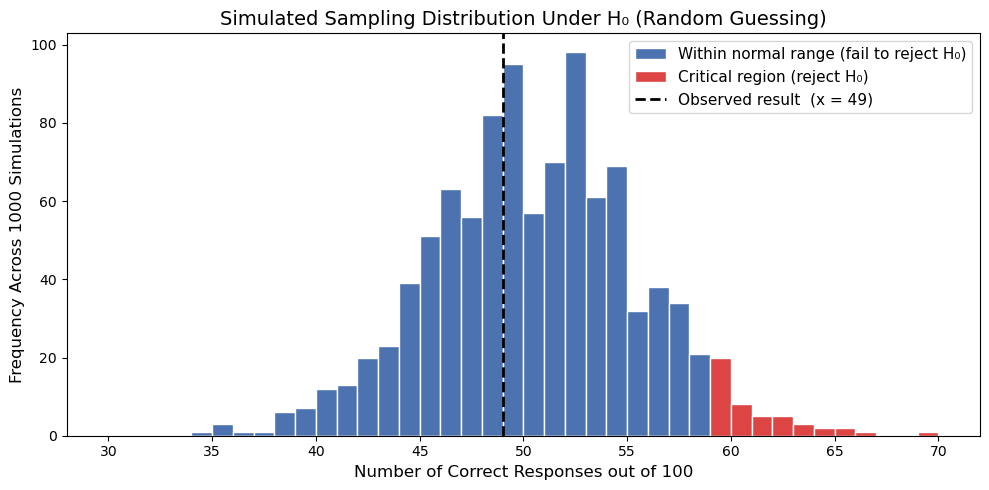

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 5))

# Separate results into normal region and critical region for colouring
normal_region   = [v for v in simulation_results if v <= critical_value]
critical_region = [v for v in simulation_results if v >  critical_value]

ax.hist(normal_region,   bins=range(30, 71), color="#4C72B0", edgecolor="white", label="Within normal range (fail to reject H\u2080)")
ax.hist(critical_region, bins=range(30, 71), color="#DD4444", edgecolor="white", label="Critical region (reject H\u2080)")

# Mark the observed result
ax.axvline(x=x, color="black", linewidth=2, linestyle="--", label="Observed result  (x = " + str(x) + ")")

ax.set_title("Simulated Sampling Distribution Under H\u2080 (Random Guessing)", fontsize=14)
ax.set_xlabel("Number of Correct Responses out of 100",                        fontsize=12)
ax.set_ylabel("Frequency Across " + str(n_simulations) + " Simulations",      fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

#### Interpreting the Result

The blue region of the chart represents outcomes that are completely normal under H₀ — results we would expect to see regularly if every student were simply guessing. The red region represents the critical zone: results so high that they would only occur about 5% of the time by pure chance.

Our observed result of **x = 49** sits squarely in the middle of the blue region. It is almost exactly what we would predict if everyone were guessing randomly. There is nothing unusual about it at all.

**Conclusion:** We **fail to reject H₀**. The data does not give us evidence that the class performed better than random chance. Based on this experiment, we cannot conclude that extrasensory perception is at work.

Note that this does not *prove* ESP is impossible — it simply means the evidence collected was not strong enough to overturn our default assumption of random chance.

---

## 5. Exercises — Formulating Hypotheses for Business Questions

For each scenario below:

1. **Restate the statistics hypothesis** in your own words: which specific characteristics of the data are we testing?
2. **Write the null hypothesis (H₀)*:  the default, "nothing is happening" claim, expressed mathematically.
3. **Write the alternative hypothesis (H₁)**: the claim we are trying to find evidence for, expressed mathematically.

Use the following notation:
- **μ** for a population mean
- **p** for a population proportion
- **μ₀** for the known or assumed baseline value

---

### Exercise 1 — E-Commerce Conversion Rate

An e-commerce company has historically maintained a checkout conversion rate of **12%** (meaning 12% of visitors who reach the checkout page complete a purchase). The product team redesigned the checkout flow and wants to know whether the new design **improved** the conversion rate. They collect data from 500 sessions and observe a conversion rate of 14.5%.

**Statistical Hypothesis:** *(write your interpretation here)*

**Null Hypothesis (H₀):** 

**Alternative Hypothesis (H₁):** 

---

### Exercise 2 — Customer Satisfaction Score

A telecom company tracks customer satisfaction using a **Net Promoter Score (NPS)**. Historically, the company's average NPS has been **42**. After rolling out a new customer service training program, the operations team surveys 80 customers and records a mean NPS of **46**. They want to know whether the training **increased** customer satisfaction.

**Statistical Hypothesis:** *(write your interpretation here)*

**Null Hypothesis (H₀):** 

**Alternative Hypothesis (H₁):** 

---

### Exercise 3 — Restaurant Ticket Size

A casual dining chain believes its average customer ticket (total spend per table) is **$18.50**. A regional manager suspects that a new upselling training program has **changed** the average ticket size — either up or down. After the training, a sample of 60 tickets shows a mean of **$20.10**.

**Statistical Hypothesis:** *(write your interpretation here)*

**Null Hypothesis (H₀):** 

**Alternative Hypothesis (H₁):** 

---

### Exercise 4 — Warehouse Processing Time

A logistics company reports that its workers take an average of **8.4 minutes** to process a package. After deploying new warehouse management software, a supervisor measures the processing time for 50 workers and finds a mean of **7.9 minutes**. The company wants to know whether the software **reduced** processing time.

**Statistical Hypothesis:** *(write your interpretation here)*

**Null Hypothesis (H₀):** 

**Alternative Hypothesis (H₁):** 


---

### Exercise 5 — Online Ad Click-Through Rate

A digital marketing team runs display ads that have historically achieved a **3.5% click-through rate (CTR)**. A new ad creative was tested on a sample of **500 impressions** and produced a CTR of **2.8%**. The team wants to determine whether the new creative is **underperforming** compared to the historical baseline.

**Statistical Hypothesis:** *(write your interpretation here)*

**Null Hypothesis (H₀):** 

**Alternative Hypothesis (H₁):** 

---

## 5. Solutions

<details>
<summary><strong>Click to reveal solutions</strong></summary>

---

#### Exercise 1 — E-Commerce Conversion Rate

**Statistical Hypothesis:** The redesigned checkout flow will result in a higher checkout conversion rate than the original checkout process.

**H₀:** p = 0.12 — The conversion rate is unchanged; the redesign had no effect.

**H₁:** p > 0.12 — The conversion rate increased after the redesign. *(One-tailed, upper)*

---

#### Exercise 2 — Customer Satisfaction Score

**Statistical Hypothesis:** The new customer service training program will result in a higher average NPS than the original customer service training program.

**H₀:** μ = 42 — The training had no effect; the mean NPS is still 42.

**H₁:** μ > 42 — The mean NPS increased after the training program. *(One-tailed, upper)*

---

#### Exercise 3 — Restaurant Ticket Size

**Statistical Hypothesis:** The redesigned training program that promotes upselling resulted in a higher average total spend per table.

**H₀:** μ = 18.50 — The training had no effect; the average ticket size is unchanged.

**H₁:** μ ≠ 18.50 — The average ticket size changed in either direction. *(Two-tailed)*

---

#### Exercise 4 — Warehouse Processing Time

**Statistical Hypothesis:** The new software tool resulted in a lower average processing time.

**H₀:** μ = 8.4 — The software had no effect; mean processing time is still 8.4 minutes.

**H₁:** μ < 8.4 — Mean processing time decreased after deploying the software. *(One-tailed, lower)*

---

#### Exercise 5 — Online Ad Click-Through Rate

**Statistical Hypothesis:** The new advertisement resulted in a lower click-through rate than the original ad.

**H₀:** p = 0.035 — The new creative performs the same as historical ads; the CTR is unchanged.

**H₁:** p < 0.035 — The new creative produces a lower click-through rate. *(One-tailed, lower)*

</details>